# Task 4

*Добавьте skip-connection. Выведите summary модели, посмотрите на графики обучения, сделайте выводы.*

---



In [ ]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # использую gpu если есть
print(device)

cuda


In [ ]:
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
from torchvision import transforms

# для аугментации
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # переворачиваем горизонтально с вероятностью 50%
    transforms.RandomRotation(degrees=10), # рандомно поворачиваем на 10 градусов
    transforms.RandomCrop(size=28, padding=2), # добавляет паддинг и вырезает в рандомном месте картинку 28x28
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # brightness - просто меняет яркость, сontrast - белые пиксели приближает к белым, а черные к черным.
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # ([0, 1] -> [-1,1])
])

test_dw = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # ([0, 1] -> [-1,1])
])


# откалибруем данные через ToTensor, чтобы значения были в диапазоне от 0.0 до 1.0 для каждого канала
train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=train_augmentation,
) # для обучения

test_data = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=test_dw
) # для тестинга

train_data.data.shape, test_data.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

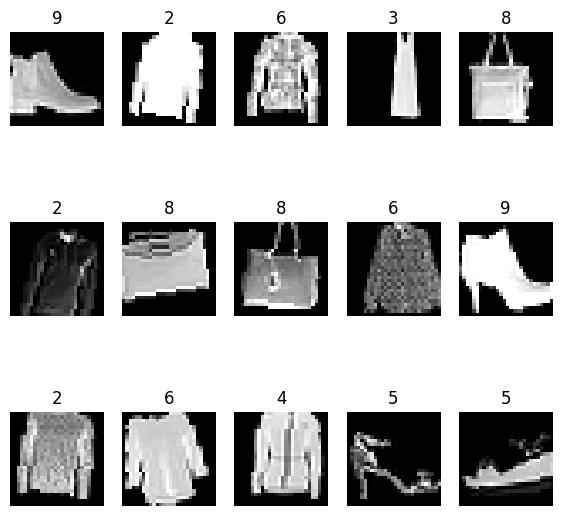

In [ ]:
import matplotlib.pyplot as plt

def visualize(data): # визуализируем датасет
  fig = plt.figure(figsize=(7, 7))

  cols, rows = 5, 3

  for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(data), size=(1,), device=device).item() # рандомная картинка, используем сразу GPU для рандома
    img, label = data[sample_idx]

    fig.add_subplot(rows, cols, i)

    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

  plt.show()

visualize(train_data) # визуализация

In [ ]:
!pip install torchinfo

In [ ]:
from torch import nn

class ResBlock(nn.Module): # skip-connection блок
  def __init__(self, channel1, channel2):
    super().__init__()
    self.model = nn.Sequential(
        nn.Conv2d(in_channels=channel1, out_channels=channel2, kernel_size=3, padding=1),
        nn.BatchNorm2d(channel2),
        nn.ReLU(),
        nn.Conv2d(in_channels=channel2, out_channels=channel2, kernel_size=3, padding=1),
        nn.BatchNorm2d(channel2)
    ) # resnet - блок
    self.relu = nn.ReLU()
    self.conv = nn.Conv2d(in_channels=channel1, out_channels=channel2, kernel_size=1) # если channel1 != channel2, то нам нужно количество каналов сделать одинаковым, с помощью фильтра 1x1

  def forward(self, x):
    out = self.model(x)
    return self.relu(out + self.conv(x))


In [ ]:
class ResNet(nn.Module):
  def __init__(self, dropout_rate): # настройка
    super().__init__()
    self.model = nn.Sequential(
        # использую 3x3 по аналогии с VGG, который доказал эффективность
        #также, чем глубже мы идем, тем больше фильтров можно ставить

        # 1 свертка
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), # (32, 28, 28)
        nn.BatchNorm2d(32), # для каждого канала выходного тензора
        nn.ReLU(), # функция активации
        nn.MaxPool2d(kernel_size=2), # (32, 14, 14)

        ResBlock(32, 32),

        # 2 свертка
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # (64, 14, 14)
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2), #(64, 7, 7)

        # Skip-connections
        ResBlock(64, 128), # (128, 7, 7)
        ResBlock(128, 128), # (128, 7, 7)

        # 3 свертка
        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), # (128, 7, 7)
        nn.BatchNorm2d(256),
        nn.ReLU(),

        # Skip-connections
        ResBlock(256, 256), # (256, 7, 7)
        ResBlock(256, 512), # (512, 7, 7)

        # Полносвязная нейронка
        nn.Flatten(), # 512 * 7 * 7
        nn.Linear(25088, 128),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        # Решил добавить еще один слой, потому что в первый раз застряло на 90% accuracy
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        # выходной слой
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)


# Выведем summary модели

from torchinfo import summary

fashion_classifier = ResNet(dropout_rate=0.1).to(device)
print(summary(fashion_classifier, input_size=(1, 1, 28, 28)))

if torch.cuda.device_count() > 1:
    fashion_classifier = torch.nn.DataParallel(fashion_classifier) # распараллеливание работы между GPU

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 32, 28, 28]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 28, 28]           64
│    └─ReLU: 2-3                         [1, 32, 28, 28]           --
│    └─MaxPool2d: 2-4                    [1, 32, 14, 14]           --
│    └─ResBlock: 2-5                     [1, 32, 14, 14]           --
│    │    └─Sequential: 3-1              [1, 32, 14, 14]           18,624
│    │    └─Conv2d: 3-2                  [1, 32, 14, 14]           1,056
│    │    └─ReLU: 3-3                    [1, 32, 14, 14]           --
│    └─Conv2d: 2-6                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-7                  [1, 64, 14, 14]           128
│    └─ReLU: 2-8                         [1, 64, 14, 14]           --
│ 

In [ ]:
from torch import optim
from torch.utils.data import DataLoader

optimizer = torch.optim.SGD(fashion_classifier.parameters(), lr=0.001, momentum=0.9) # изменил, для более плавного перехода, добавил momentum чтобы ускорить обучение
criterion = torch.nn.CrossEntropyLoss()

import os
# разделим данные на батчи
batch_size = 256
num_of_epochs = 100

num_workers = min(8, os.cpu_count()) # для многопоточности

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True, prefetch_factor=4) # обучающая выборка
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True, prefetch_factor=4) # тестовая выборка

# persistent_workers позволяет переиспользовать потоки
# pinned_memory позволяет использовать область памяти ОЗУ которая не выгружает ее в диск
# prefetch_factor позволяет во время каждой загрузки, предзагружать еще 4 батча

In [ ]:
!pip install pytorch-ignite

In [ ]:
from ignite.engine import create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, Precision, Recall, Fbeta

trainer = create_supervised_trainer(fashion_classifier, optimizer, criterion, device)

metrics = {
    "accuracy": Accuracy(),
    "precision": Precision(average=True),
    "recall": Recall(average=True),
    "f1_score": Fbeta(average=True, beta=1.0),
    "loss": Loss(criterion)
}

train_evaluator = create_supervised_evaluator(fashion_classifier, metrics=metrics, device=device) # проверка на обучающей выборке
test_evaluator = create_supervised_evaluator(fashion_classifier, metrics=metrics, device=device) # проверка на тестовой выборке

In [ ]:
from IPython.display import clear_output

def show_loss(train_losses, test_losses, train_accuracies, test_accuracies):
  clear_output()

  plt.figure(figsize=(15,15))

  plt.subplot(2, 2, 1)
  plt.title('Train Loss')
  plt.plot(np.arange(len(train_losses)), train_losses)  # лосс обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 2)
  plt.title('Test Loss')
  plt.plot(np.arange(len(test_losses)), test_losses) # лосс тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 3)
  plt.title('Train Accuracy')
  plt.plot(np.arange(len(train_accuracies)), train_accuracies) # accuracy обучающей выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.subplot(2, 2, 4)
  plt.title('Test Accuracy')
  plt.plot(np.arange(len(test_accuracies)), test_accuracies) # accuracy тестовой выборки
  plt.yscale('log')
  plt.grid()
  plt.legend()

  plt.show()


In [ ]:
from ignite.engine import Events


train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

test_y_true = []
test_y_pred = []

experiment = []

best_avg_error, best_epoch = float("inf"), 0

def compute_epoch_results(engine):
    global best_avg_error, best_epoch, experiment
    train_evaluator.run(train_loader)
    test_evaluator.run(test_loader)
    # Сохраняем метрики
    train_losses.append(train_evaluator.state.metrics["loss"])
    test_losses.append(test_evaluator.state.metrics["loss"])
    train_accuracies.append(train_evaluator.state.metrics["accuracy"])
    test_accuracies.append(test_evaluator.state.metrics["accuracy"])

    if test_losses[-1] < best_avg_error: # проверяем есть ли какие-либо улучшения
        best_avg_error = test_losses[-1]
        experiment = [{
            "Min Validation Loss": best_avg_error,
            "Accuracy": test_evaluator.state.metrics["accuracy"],
            "Precision": test_evaluator.state.metrics["precision"],
            "Recall": test_evaluator.state.metrics["recall"],
            "F1-score": test_evaluator.state.metrics["f1_score"]
        }]

trainer.add_event_handler(Events.EPOCH_COMPLETED, compute_epoch_results)


trainer.add_event_handler(
    Events.EPOCH_COMPLETED(every=10),
    lambda engine: show_loss(train_losses, test_losses, train_accuracies, test_accuracies)
)

def log_epoch_results(engine, label=""):
    result = ', '.join([f"{m} = {v}" for m, v in engine.state.metrics.items()])
    print(f"{label} Res:", result)

train_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Train")
test_evaluator.add_event_handler(Events.EPOCH_COMPLETED, log_epoch_results, label="Valid")

In [ ]:
from ignite.handlers.param_scheduler import ReduceLROnPlateauScheduler
from ignite.handlers import EarlyStopping

scheduler = ReduceLROnPlateauScheduler(
    optimizer,
    mode='min',
    metric_name="loss",
    factor=0.1,
    patience=3, # поменял с предыдущей модели чтобы быстрее срабатывыло
    threshold=0.05
)

test_evaluator.add_event_handler(Events.COMPLETED, scheduler) # снижает lr у оптимайзера, если не было улучшений

early_stopping = EarlyStopping(patience=10, score_function=lambda x: -test_evaluator.state.metrics["loss"] , trainer=trainer) # для своевременной остановки если не было улучшений

test_evaluator.add_event_handler(Events.COMPLETED, early_stopping) # если при запуске валидации не было улучшений останавливаем

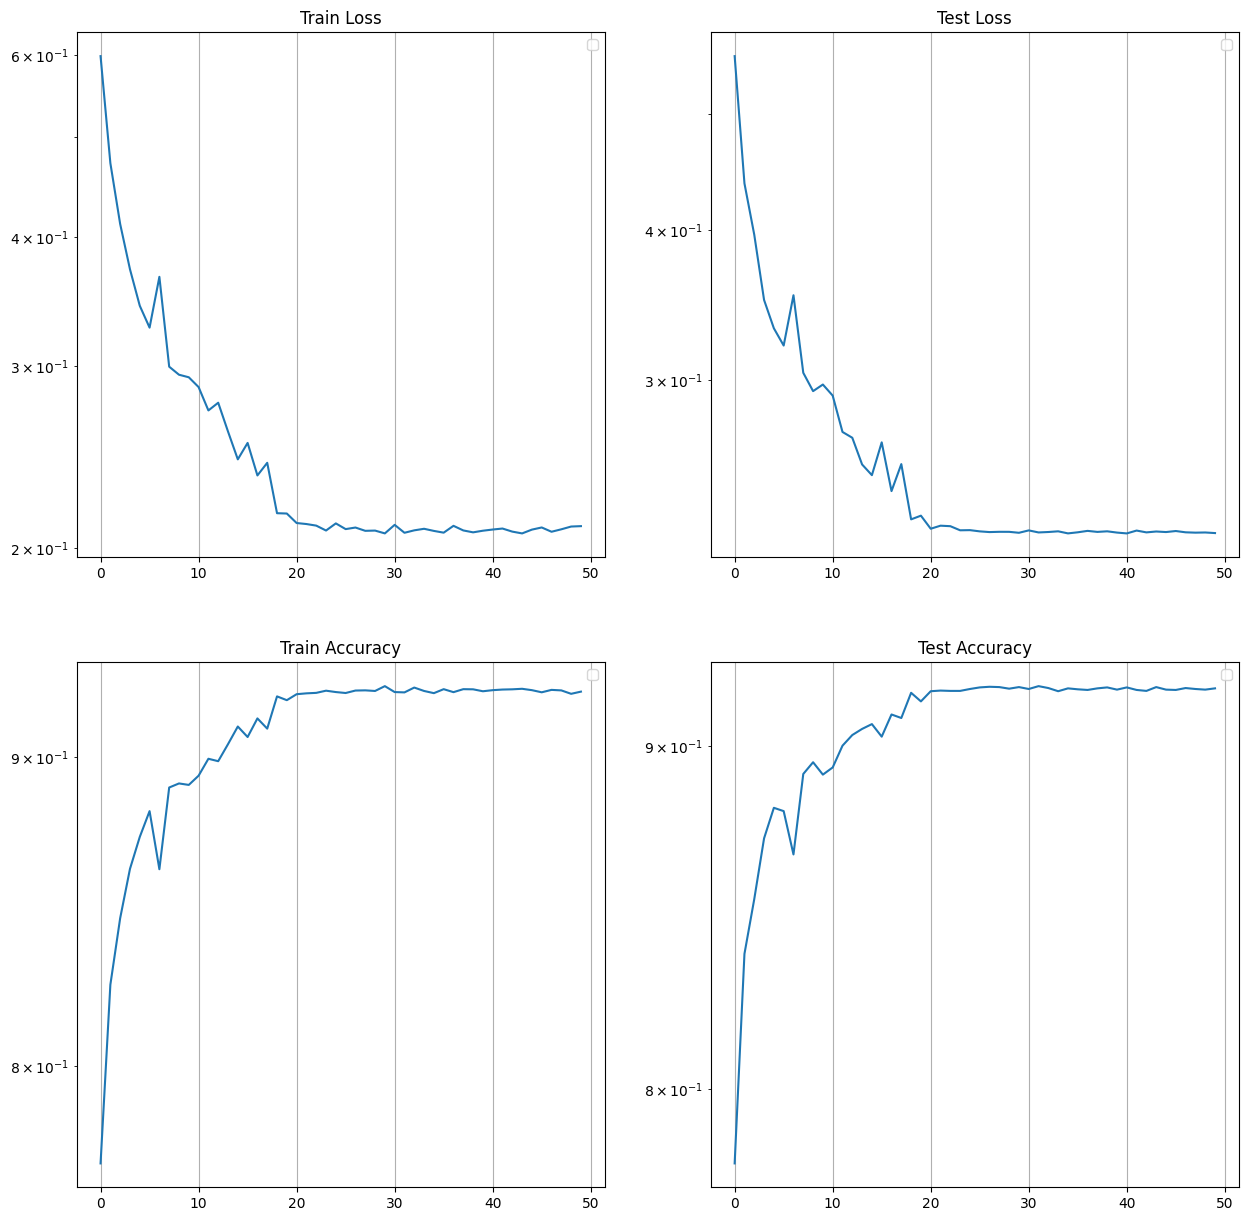

Train Res: accuracy = 0.9231833333333334, precision = 0.9229932668677939, recall = 0.9231833333333332, f1_score = 0.9230364363880963, loss = 0.20985919596354166
Valid Res: accuracy = 0.9184, precision = 0.9183375719712729, recall = 0.9184000000000001, f1_score = 0.918339017631007, loss = 0.2229423095703125
Train Res: accuracy = 0.92325, precision = 0.9229235647434931, recall = 0.92325, f1_score = 0.9230245804882303, loss = 0.20754842122395833
Valid Res: accuracy = 0.9185, precision = 0.91836756401696, recall = 0.9185000000000001, f1_score = 0.9183783950636887, loss = 0.22387705078125
Train Res: accuracy = 0.9236833333333333, precision = 0.9234324411581719, recall = 0.9236833333333333, f1_score = 0.9234732916085278, loss = 0.2067818359375
Valid Res: accuracy = 0.918, precision = 0.9179932368210656, recall = 0.9179999999999999, f1_score = 0.9179348692618721, loss = 0.2239399169921875
Train Res: accuracy = 0.92255, precision = 0.9222174472845885, recall = 0.92255, f1_score = 0.92229559817

In [ ]:
trainer.run(train_loader, max_epochs=num_of_epochs)

In [ ]:
import pandas as pd

report = pd.DataFrame(experiment)

print(report)

# Вывод:

Долго пытался выжать максимум точности, и в итоге удалось остановиться на ~92%. Для модели использовал несколько блоков ResNet, что значительно улучшило точность на аугментированном датасете. Сразу видно, что ResNet существенно улучшает модель.

Отчет:


 |Min Validation Loss | Accuracy | Precision | Recall |  F1-score |
 |--------------------|----------|-----------|--------|-----------|
 |           0.223572|   0.9176 |  0.918 | 0.9176 | 0.9176  |



**До этого обучал модель, точность составила 90%. Чтобы достичь хотя бы 92%, добавил еще один блок ResNet в начальный слой, из-за чего обучение затянулось, и, к сожалению, я не успел отправить работу вовремя. Буду признателен, если вы не снизите балл за это.**